# LSTM Deep Learning Model for CPU Usage Forecasting

This notebook demonstrates how to use an LSTM (Long Short-Term Memory) neural network for time series forecasting. We will:
- Load and inspect the feature-engineered dataset
- Prepare data as sequences for LSTM
- Build and train an LSTM model
- Evaluate performance
- Save the trained model

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

## Load and Inspect Data
Load the train, validation, and test splits. Display the first few rows and basic statistics.

In [3]:
# Load the feature-engineered dataset splits
train = pd.read_csv('../data/splits/train.csv', parse_dates=['date'])
val = pd.read_csv('../data/splits/val.csv', parse_dates=['date'])
test = pd.read_csv('../data/splits/test.csv', parse_dates=['date'])

print('Train shape:', train.shape)
print('Validation shape:', val.shape)
print('Test shape:', test.shape)

display(train.head())
display(train.describe())

Train shape: (708, 33)
Validation shape: (180, 33)
Test shape: (192, 33)


,date,region,resource_type,usage_cpu,usage_storage,users_active,econ_index,cloud_market_demand,holiday,day_of_week,...,storage_usage_rollmax_3,storage_usage_rollmin_3,cpu_usage_rollmean_7,cpu_usage_rollmax_7,cpu_usage_rollmin_7,storage_usage_rollmean_7,storage_usage_rollmax_7,storage_usage_rollmin_7,cpu_utilization_ratio,storage_efficiency
0,2023-01-01,eastus,Container,70,621,414,104.97,0.99,True,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.707071,0.311278
1,2023-01-01,northeurope,Container,82,959,221,104.97,0.99,True,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.828283,0.485324
2,2023-01-01,northeurope,Storage,51,1715,476,104.97,0.99,True,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.520408,0.873218
3,2023-01-01,northeurope,VM,73,1937,493,104.97,0.99,True,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.737374,0.971414
4,2023-01-01,eastus,Storage,92,1595,388,104.97,0.99,True,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.929293,0.800703


,date,usage_cpu,usage_storage,users_active,econ_index,cloud_market_demand,day_of_week,month,quarter,is_weekend,...,storage_usage_rollmax_3,storage_usage_rollmin_3,cpu_usage_rollmean_7,cpu_usage_rollmax_7,cpu_usage_rollmin_7,storage_usage_rollmean_7,storage_usage_rollmax_7,storage_usage_rollmin_7,cpu_utilization_ratio,storage_efficiency
count,708,708.000000,708.000000,708.000000,708.000000,708.000000,708.000000,708.000000,708.0,708.000000,...,684.00000,684.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,708.000000,708.000000
mean,2023-01-30 00:00:00,74.936441,1251.706215,351.134181,98.535085,0.995763,2.966102,1.474576,1.0,0.288136,...,1621.52924,858.918129,75.113657,93.484277,55.844340,1243.311545,1799.199686,651.823899,0.757576,0.631853
min,2023-01-01 00:00:00,50.000000,500.000000,200.000000,73.800000,0.800000,0.000000,1.000000,1.0,0.000000,...,553.00000,500.000000,58.285714,69.000000,50.000000,688.142857,1023.000000,500.000000,0.505051,0.251254
25%,2023-01-15 00:00:00,62.000000,862.000000,280.750000,93.980000,0.940000,1.000000,1.000000,1.0,0.000000,...,1455.50000,590.000000,71.142857,90.750000,51.000000,1124.500000,1719.000000,533.000000,0.626263,0.437177
50%,2023-01-30 00:00:00,75.000000,1291.500000,350.500000,99.280000,0.990000,3.000000,1.000000,1.0,0.000000,...,1687.50000,790.000000,75.285714,96.000000,54.000000,1245.928571,1832.000000,589.000000,0.757576,0.652334
75%,2023-02-14 00:00:00,87.000000,1622.250000,426.000000,103.310000,1.050000,5.000000,2.000000,1.0,1.000000,...,1850.00000,1058.500000,79.321429,97.000000,59.000000,1372.428571,1934.000000,736.000000,0.887755,0.820793
max,2023-02-28 00:00:00,99.000000,1995.000000,499.000000,118.860000,1.250000,6.000000,2.000000,1.0,1.000000,...,1995.00000,1823.000000,90.142857,99.000000,75.000000,1710.142857,1995.000000,1543.000000,1.000000,1.000000
std,NaN,14.600098,440.175571,86.943854,8.569861,0.098363,2.043095,0.499706,0.0,0.453215,...,290.95893,311.090881,5.714503,5.375776,5.576891,175.254693,164.854246,159.984833,0.147612,0.222165


## Prepare Data for LSTM
We will select features, scale them, and create sequences suitable for LSTM input.

In [4]:
# Select a region for univariate LSTM (e.g., most common region)
region = train['region'].mode()[0]
print(f"Selected region for LSTM: {region}")

train_region = train[train['region'] == region].copy()
val_region = val[val['region'] == region].copy()
test_region = test[test['region'] == region].copy()

# Set date as index
train_region.set_index('date', inplace=True)
val_region.set_index('date', inplace=True)
test_region.set_index('date', inplace=True)

# Select features and target
ignore_cols = ['region', 'resource_type', 'usage_storage']
feature_cols = [col for col in train_region.columns if col not in ignore_cols]

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_region[feature_cols])
val_scaled = scaler.transform(val_region[feature_cols])
test_scaled = scaler.transform(test_region[feature_cols])

# Sequence creation function
def create_sequences(data, target_col, seq_length=30):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, :])
        y.append(data[i, feature_cols.index(target_col)])
    return np.array(X), np.array(y)

seq_length = 30
X_train, y_train = create_sequences(train_scaled, 'usage_cpu', seq_length)
X_val, y_val = create_sequences(val_scaled, 'usage_cpu', seq_length)
X_test, y_test = create_sequences(test_scaled, 'usage_cpu', seq_length)

print('LSTM train shape:', X_train.shape, y_train.shape)
print('LSTM val shape:', X_val.shape, y_val.shape)
print('LSTM test shape:', X_test.shape, y_test.shape)

Selected region for LSTM: eastus
LSTM train shape: (147, 30, 29) (147,)
LSTM val shape: (15, 30, 29) (15,)
LSTM test shape: (18, 30, 29) (18,)


## Build and Train LSTM Model
Define the LSTM architecture, compile, and train the model using the training data. Use early stopping to prevent overfitting.

In [5]:
# Define LSTM model architecture
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model with early stopping
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        24,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,177 (102.25 KB)

 Trainable params: 26,177 (102.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 1.0283 - val_loss: 0.9945
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 1.0283 - val_loss: 0.9945
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.9954 - val_loss: 0.9911
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.9954 - val_loss: 0.9911
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.0594 - val_loss: 0.9900
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.0594 - val_loss: 0.9900
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.0262 - val_loss: 0.9890
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.0262 - val_loss: 0.9890
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.9741 - val_loss: 0.9880
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.9741 - val_loss: 0.9880
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.9893 - val_loss: 0.9876
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.9893 - val_los

## Evaluate LSTM Model
Check predictions on the validation and test sets. Report MAE and RMSE. Plot actual vs. predicted values.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
Validation MAE: 0.81, RMSE: 0.98
Test MAE: 0.99, RMSE: 1.11
Validation MAE: 0.81, RMSE: 0.98
Test MAE: 0.99, RMSE: 1.11


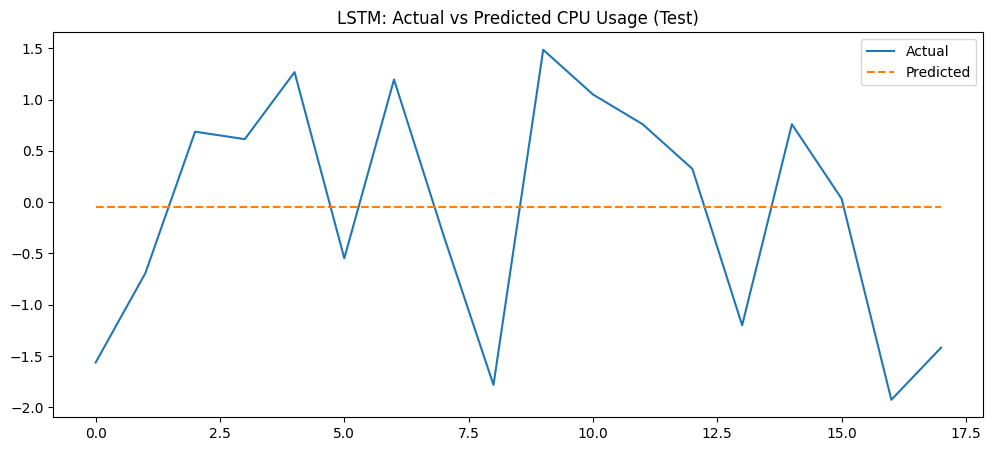

In [6]:
# Predict on validation and test sets
val_pred = model.predict(X_val).flatten()
test_pred = model.predict(X_test).flatten()

# Evaluation metrics
mae_val = mean_absolute_error(y_val, val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val, val_pred))
mae_test = mean_absolute_error(y_test, test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, test_pred))
print(f"Validation MAE: {mae_val:.2f}, RMSE: {rmse_val:.2f}")
print(f"Test MAE: {mae_test:.2f}, RMSE: {rmse_test:.2f}")

# Plot actual vs predicted for test set
plt.figure(figsize=(12, 5))
plt.plot(range(len(y_test)), y_test, label='Actual')
plt.plot(range(len(test_pred)), test_pred, label='Predicted', linestyle='--')
plt.title('LSTM: Actual vs Predicted CPU Usage (Test)')
plt.legend()
plt.show()

## Save the Trained LSTM Model
Save the trained LSTM model and scaler for later use or deployment.

In [7]:
os.makedirs('../models', exist_ok=True)
model.save('../models/lstm_model.h5')
joblib.dump(scaler, '../models/lstm_scaler.pkl')
print('LSTM model and scaler saved to models/.')

LSTM model and scaler saved to models/.


## Additional Evaluation Metrics: MAPE and Forecast Bias
Calculate MAPE (Mean Absolute Percentage Error) and forecast bias for the LSTM model on the test set.

In [8]:
# MAPE
mape = np.mean(np.abs((y_test - test_pred) / y_test)) * 100
print(f"Test MAPE: {mape:.2f}%")

# Forecast Bias
bias = np.mean(test_pred - y_test)
print(f"Forecast Bias: {bias:.2f}")

Test MAPE: 107.95%
Forecast Bias: 0.03
